# CSIT 598 - Assignment 1
## 07. Performance Comparison and Analysis

Aggregating all metrics, comparing models and finding:
- Which model performed best?
- What are the trade-offs?

In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
project_root = Path.cwd().parent
metrics_dir = project_root / 'results' / 'metrics'

metrics_files = [
    'decision_tree_metrics.json',
    'gaussian_nb_metrics.json',
    'multinomial_nb_metrics.json',
    'svm_linear_metrics.json',
    'svm_rbf_metrics.json',
    'knn_metrics.json',
    'bagging_metrics.json',
    'random_forest_metrics.json',
    'adaboost_metrics.json',
    'xgboost_metrics.json',
]

records = []
missing = []

for file_name in metrics_files:
    file_path = metrics_dir / file_name
    if not file_path.exists():
        missing.append(file_name)
        continue
    with open(file_path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    records.append(payload)

print(f'Loaded metrics files: {len(records)}')
if missing:
    print('Missing files (skipped):')
    for item in missing:
        print('-', item)

Loaded metrics files: 10


In [13]:
summary_df = pd.DataFrame(records)

if summary_df.empty:
    raise ValueError('No metrics records found. Run algorithm notebooks first.')

column_map = {
    'model_name': 'Model',
    'accuracy': 'Accuracy',
    'precision_macro': 'PrecisionMacro',
    'recall_macro': 'RecallMacro',
    'f1_macro': 'F1Macro',
    'train_time_sec': 'TrainTimeSec',
    'pred_time_sec': 'PredTimeSec',
}

available_columns = [col for col in column_map if col in summary_df.columns]
summary_table = summary_df[available_columns].rename(columns=column_map)

for metric_col in ['Accuracy', 'PrecisionMacro', 'RecallMacro', 'F1Macro', 'TrainTimeSec', 'PredTimeSec']:
    if metric_col in summary_table.columns:
        summary_table[metric_col] = pd.to_numeric(summary_table[metric_col], errors='coerce')

summary_table = summary_table.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
summary_table['Rank'] = summary_table.index + 1

display(summary_table)

comparison_csv = metrics_dir / 'model_comparison_summary.csv'
summary_table.to_csv(comparison_csv, index=False)
print(f'Saved summary table: {comparison_csv}')

,Model,Accuracy,PrecisionMacro,RecallMacro,F1Macro,TrainTimeSec,PredTimeSec,Rank
0,xgboost,0.9695,0.969287,0.969248,0.969251,192.533378,0.086932,1
1,random_forest,0.9687,0.968503,0.968425,0.968445,5.822964,0.066750,2
2,SVM_RBF,0.9588,0.959314,0.958357,0.958702,80.995505,61.828007,3
3,bagging,0.9487,0.948296,0.948130,0.948134,35.008062,0.201648,4
4,KNN,0.9483,0.948669,0.947574,0.947838,0.025007,2.370804,5
5,SVM_Linear,0.9347,0.934203,0.933663,0.933751,112.918122,10.216698,6
6,DecisionTree,0.8808,0.879387,0.879020,0.879071,6.351165,0.012799,7
7,adaboost,0.8324,0.835109,0.830872,0.831857,118.388637,0.147487,8
8,MultinomialNB,0.8307,0.836435,0.827534,0.828956,0.017820,0.020353,9
9,GaussianNB,0.5359,0.669067,0.528327,0.475355,0.090754,0.042257,10


Saved summary table: /Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/model_comparison_summary.csv


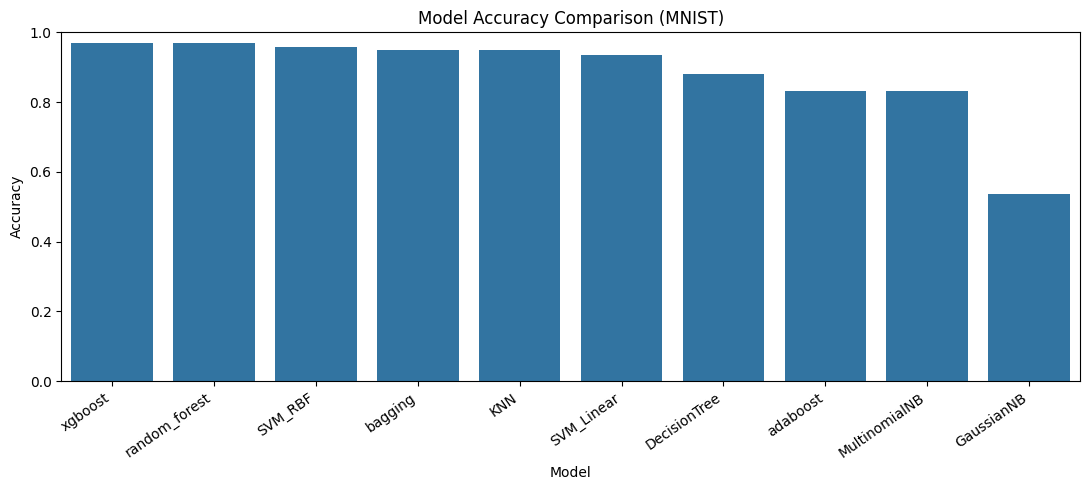

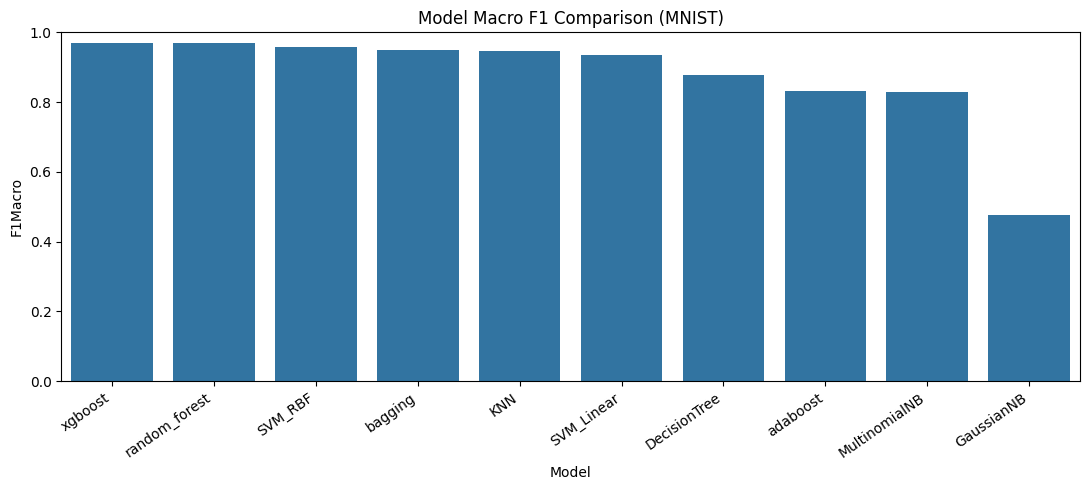

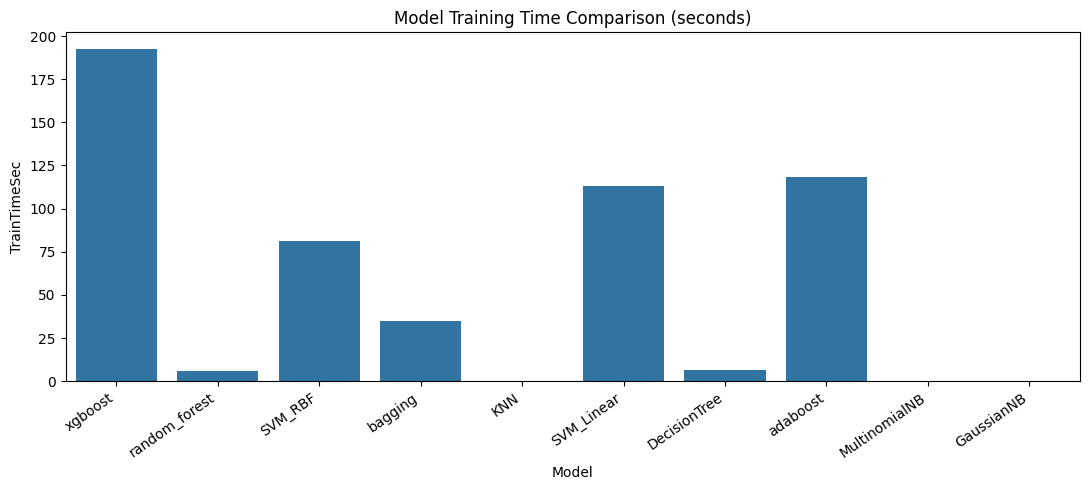

Final observations:
- Best-performing model by accuracy: xgboost (0.9695)
- Fastest training model: MultinomialNB (0.0178 sec)
- Trade-off: highest-accuracy models are generally slower than the fastest baselines.

Saved artifacts:
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/figures/accuracy_comparison.png
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/figures/f1_comparison.png
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/figures/train_time_comparison.png
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/final_analysis.txt


In [14]:
figures_dir = project_root / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# 1) Accuracy comparison
plt.figure(figsize=(11, 5))
sns.barplot(data=summary_table, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison (MNIST)')
plt.xticks(rotation=35, ha='right')
plt.ylim(0.0, 1.0)
plt.tight_layout()
acc_plot_path = figures_dir / 'accuracy_comparison.png'
plt.savefig(acc_plot_path, dpi=150)
plt.show()

# 2) Macro F1 comparison
if 'F1Macro' in summary_table.columns:
    plt.figure(figsize=(11, 5))
    sns.barplot(data=summary_table, x='Model', y='F1Macro')
    plt.title('Model Macro F1 Comparison (MNIST)')
    plt.xticks(rotation=35, ha='right')
    plt.ylim(0.0, 1.0)
    plt.tight_layout()
    f1_plot_path = figures_dir / 'f1_comparison.png'
    plt.savefig(f1_plot_path, dpi=150)
    plt.show()

# 3) Training time comparison
if 'TrainTimeSec' in summary_table.columns:
    plt.figure(figsize=(11, 5))
    sns.barplot(data=summary_table, x='Model', y='TrainTimeSec')
    plt.title('Model Training Time Comparison (seconds)')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    train_time_plot_path = figures_dir / 'train_time_comparison.png'
    plt.savefig(train_time_plot_path, dpi=150)
    plt.show()

best_row = summary_table.iloc[0]
fastest_row = summary_table.sort_values('TrainTimeSec', ascending=True).iloc[0]
best_model = best_row['Model']
best_acc = float(best_row['Accuracy'])
fastest_model = fastest_row['Model']
fastest_train_time = float(fastest_row['TrainTimeSec'])

analysis_lines = [
    f"Best-performing model by accuracy: {best_model} ({best_acc:.4f})",
    f"Fastest training model: {fastest_model} ({fastest_train_time:.4f} sec)",
    'Trade-off: highest-accuracy models are generally slower than the fastest baselines.',
]

analysis_path = metrics_dir / 'final_analysis.txt'
with open(analysis_path, 'w', encoding='utf-8') as f:
    for line in analysis_lines:
        f.write(line + '\n')

print('Final observations:')
for line in analysis_lines:
    print('-', line)

print('\nSaved artifacts:')
print(acc_plot_path)
if 'f1_plot_path' in locals():
    print(f1_plot_path)
if 'train_time_plot_path' in locals():
    print(train_time_plot_path)
print(analysis_path)